In [1]:
# All Imports
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from datetime import datetime
from collections import Counter
import optuna
# Scikit-learn imports
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine learning models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# XGBoost (Transformer-based)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Hyperparameter optimization
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

# Evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, matthews_corrcoef)

import torch

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU Not Found")

# Visualization settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

GPU: NVIDIA GeForce RTX 4060


In [16]:
# Feature Engineering and Preprocessing
# Load Datasets

df = pd.read_csv('./data/raw/finguard-fraud-detection-dataset.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [17]:
df.shape

(6362620, 11)

In [18]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [19]:
print("\n Class Distribution:")
print(f"  - Fraud (isFraud=1): {df['isFraud'].sum():,} ({df['isFraud'].sum()/len(df)*100:.4f}%)")
print(f"  - Non-Fraud (isFraud=0): {len(df)-df['isFraud'].sum():,} ({100-df['isFraud'].sum()/len(df)*100:.4f}%)")


 Class Distribution:
  - Fraud (isFraud=1): 8,213 (0.1291%)
  - Non-Fraud (isFraud=0): 6,354,407 (99.8709%)


In [20]:
# Remove sensitive columns
sensitive_cols = ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 
                  'newbalanceDest', 'nameOrig', 'nameDest']

df_clean = df.drop(sensitive_cols, axis=1)

print(f"✓ Dropped sensitive columns: {sensitive_cols}")
print(f"✓ New shape: {df_clean.shape}")
print(f"✓ Remaining columns: {df_clean.columns.tolist()}")

✓ Dropped sensitive columns: ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'nameOrig', 'nameDest']
✓ New shape: (6362620, 5)
✓ Remaining columns: ['step', 'type', 'amount', 'isFraud', 'isFlaggedFraud']


In [22]:
print(f"✓ Missing values after drop: {df_clean.isnull().sum().sum()}")

✓ Missing values after drop: 0


In [21]:
# FEATURE ENGINEERING - CATEGORICAL ENCODING
le = LabelEncoder()
df_clean['type_encoded'] = le.fit_transform(df_clean['type'])

In [23]:
# Create mapping dictionary
type_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"✓ Transaction type encoding:")
for trans_type, code in type_mapping.items():
    print(f"  - {trans_type}: {code}")

# Show distribution of transaction types
print(f"\n✓ Transaction Type Distribution:")
print(df_clean['type'].value_counts())


✓ Transaction type encoding:
  - CASH_IN: 0
  - CASH_OUT: 1
  - DEBIT: 2
  - PAYMENT: 3
  - TRANSFER: 4

✓ Transaction Type Distribution:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


In [24]:
# FEATURE ENGINEERING - TIME-BASED FEATURES
# Extract time components from step (1 step = 1 hour)
df_clean['hour_of_day'] = df_clean['step'] % 24
df_clean['day_of_week'] = (df_clean['step'] // 24) % 7
df_clean['week_of_month'] = (df_clean['step'] // 168) + 1  # 24*7=168 hours in a week

print(f"✓ Created time-based features:")
print(f"  - hour_of_day: {df_clean['hour_of_day'].min()} to {df_clean['hour_of_day'].max()}")
print(f"  - day_of_week: {df_clean['day_of_week'].min()} to {df_clean['day_of_week'].max()}")
print(f"  - week_of_month: {df_clean['week_of_month'].min()} to {df_clean['week_of_month'].max()}")

✓ Created time-based features:
  - hour_of_day: 0 to 23
  - day_of_week: 0 to 6
  - week_of_month: 1 to 5


In [25]:
# FEATURE ENGINEERING - AMOUNT TRANSFORMATIONS
# Log transformation
df_clean['log_amount'] = np.log1p(df_clean['amount'])

# Square root transformation (alternative)
df_clean['sqrt_amount'] = np.sqrt(df_clean['amount'])

# Standardized amount
mean_amount = df_clean['amount'].mean()
std_amount = df_clean['amount'].std()
df_clean['zscore_amount'] = (df_clean['amount'] - mean_amount) / std_amount

print(f"✓ Created amount transformations:")
print(f"  - log_amount: log(amount + 1)")
print(f"  - sqrt_amount: sqrt(amount)")
print(f"  - zscore_amount: standardized amount")

print(f"\n📋 Amount Statistics:")
print(df_clean['amount'].describe().round(2))

✓ Created amount transformations:
  - log_amount: log(amount + 1)
  - sqrt_amount: sqrt(amount)
  - zscore_amount: standardized amount

📋 Amount Statistics:
count     6362620.00
mean       179861.90
std        603858.23
min             0.00
25%         13389.57
50%         74871.94
75%        208721.48
max      92445516.64
Name: amount, dtype: float64


In [26]:
# High-value transaction flags (based on 200,000 threshold from dataset)
df_clean['is_high_value'] = (df_clean['amount'] > 200000).astype(int)
df_clean['is_very_high_value'] = (df_clean['amount'] > df_clean['amount'].quantile(0.99)).astype(int)

print(f"✓ Created amount flags:")
print(f"  - is_high_value: amount > 200,000 (dataset threshold)")
print(f"  - is_very_high_value: amount > 99th percentile")


✓ Created amount flags:
  - is_high_value: amount > 200,000 (dataset threshold)
  - is_very_high_value: amount > 99th percentile


In [27]:
# EATURE ENGINEERING - FRAUD PATTERN DETECTION

# Create transaction pair features
# For each transaction, check if there's a matching transaction with same amount
df_clean['amount_count'] = df_clean.groupby('amount')['step'].transform('count')
df_clean['is_duplicate_amount'] = (df_clean['amount_count'] > 1).astype(int)

# Transaction type combination features
df_clean['is_cash_out'] = (df_clean['type'] == 'CASH_OUT').astype(int)
df_clean['is_transfer'] = (df_clean['type'] == 'TRANSFER').astype(int)
df_clean['is_payment'] = (df_clean['type'] == 'PAYMENT').astype(int)
df_clean['is_cash_in'] = (df_clean['type'] == 'CASH_IN').astype(int)

print(f"✓ Created fraud pattern features:")
print(f"  - amount_count: number of transactions with same amount")
print(f"  - is_duplicate_amount: flag for duplicate amounts")
print(f"  - is_cash_out, is_transfer, is_payment, is_cash_in: one-hot flags")

✓ Created fraud pattern features:
  - amount_count: number of transactions with same amount
  - is_duplicate_amount: flag for duplicate amounts
  - is_cash_out, is_transfer, is_payment, is_cash_in: one-hot flags


In [28]:
# FEATURE ENGINEERING - RATIO AND INTERACTION FEATURES
# Transaction type frequency
type_freq = df_clean.groupby('type')['step'].transform('count')
df_clean['type_frequency'] = type_freq / len(df_clean)

# Amount vs type average
type_amount_mean = df_clean.groupby('type')['amount'].transform('mean')
df_clean['amount_vs_type_avg'] = df_clean['amount'] / (type_amount_mean + 1)

# Time-based amount ratio
step_amount_mean = df_clean.groupby('step')['amount'].transform('mean')
df_clean['amount_vs_step_avg'] = df_clean['amount'] / (step_amount_mean + 1)

print(f"✓ Created ratio features:")
print(f"  - type_frequency: relative frequency of transaction type")
print(f"  - amount_vs_type_avg: amount ratio to type average")
print(f"  - amount_vs_step_avg: amount ratio to step average")

✓ Created ratio features:
  - type_frequency: relative frequency of transaction type
  - amount_vs_type_avg: amount ratio to type average
  - amount_vs_step_avg: amount ratio to step average


In [29]:
# FEATURE ENGINEERING - FLAGGED FRAUD ANALYSIS
# Interaction features with flagged fraud
df_clean['amount_flagged_interaction'] = df_clean['amount'] * df_clean['isFlaggedFraud']
df_clean['transfer_flagged'] = df_clean['is_transfer'] * df_clean['isFlaggedFraud']
df_clean['cashout_flagged'] = df_clean['is_cash_out'] * df_clean['isFlaggedFraud']

print(f"✓ Created interaction features with isFlaggedFraud:")
print(f"  - amount_flagged_interaction: amount * isFlaggedFraud")
print(f"  - transfer_flagged: TRANSFER * isFlaggedFraud")
print(f"  - cashout_flagged: CASH_OUT * isFlaggedFraud")


✓ Created interaction features with isFlaggedFraud:
  - amount_flagged_interaction: amount * isFlaggedFraud
  - transfer_flagged: TRANSFER * isFlaggedFraud
  - cashout_flagged: CASH_OUT * isFlaggedFraud


In [30]:
# SELECT FINAL FEATURE SET
# Feature selection based on correlation analysis and domain knowledge
feature_columns = [
    # Core features
    'step',
    'amount',
    'type_encoded',
    
    # Time-based features
    'hour_of_day',
    'day_of_week',
    'week_of_month',
    
    # Amount transformations
    'log_amount',
    'sqrt_amount',
    'zscore_amount',
    'amount_vs_type_avg',
    'amount_vs_step_avg',
    
    # Categorical flags
    'is_high_value',
    'is_very_high_value',
    
    # Fraud pattern features
    'amount_count',
    'is_duplicate_amount',
    'is_cash_out',
    'is_transfer',
    'is_payment',
    'is_cash_in',
    
    # Pattern features
    'type_frequency',
    'amount_flagged_interaction',
    'transfer_flagged',
    'cashout_flagged',
    
    # Flagged indicator
    'isFlaggedFraud'
]

X = df_clean[feature_columns]
y = df_clean['isFraud']

print(f"✓ Final feature set:")
print(f"  - Number of features: {len(feature_columns)}")
print(f"  - Features: {feature_columns}")
print(f"  - Target distribution:")
print(f"    - Fraud (1): {y.sum():,} ({y.sum()/len(y)*100:.4f}%)")
print(f"    - Non-Fraud (0): {len(y) - y.sum():,} ({100 - y.sum()/len(y)*100:.4f}%)")

✓ Final feature set:
  - Number of features: 24
  - Features: ['step', 'amount', 'type_encoded', 'hour_of_day', 'day_of_week', 'week_of_month', 'log_amount', 'sqrt_amount', 'zscore_amount', 'amount_vs_type_avg', 'amount_vs_step_avg', 'is_high_value', 'is_very_high_value', 'amount_count', 'is_duplicate_amount', 'is_cash_out', 'is_transfer', 'is_payment', 'is_cash_in', 'type_frequency', 'amount_flagged_interaction', 'transfer_flagged', 'cashout_flagged', 'isFlaggedFraud']
  - Target distribution:
    - Fraud (1): 8,213 (0.1291%)
    - Non-Fraud (0): 6,354,407 (99.8709%)


In [31]:
# Save feature list for reference
os.makedirs('./reports', exist_ok=True)
with open('./reports/feature_list.txt', 'w') as f:
    for feat in feature_columns:
        f.write(f"{feat}\n")

print(f"✓ Feature list saved to ./reports/feature_list.txt")

✓ Feature list saved to ./reports/feature_list.txt


In [32]:
# HANDLE CLASS IMBALANCE - STRATIFIED SPLIT
# Stratified train-test split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"✓ Stratified split completed:")
print(f"  - Training set: {len(X_train):,} samples")
print(f"  - Test set: {len(X_test):,} samples")
print(f"  - Train fraud ratio: {y_train.sum()/len(y_train)*100:.4f}%")
print(f"  - Test fraud ratio: {y_test.sum()/len(y_test)*100:.4f}%")

✓ Stratified split completed:
  - Training set: 5,090,096 samples
  - Test set: 1,272,524 samples
  - Train fraud ratio: 0.1291%
  - Test fraud ratio: 0.1291%


In [33]:
# DATA SCALING
# Identify numerical features for scaling
numeric_features = ['step', 'amount', 'log_amount', 'sqrt_amount', 'zscore_amount',
                    'hour_of_day', 'day_of_week', 'week_of_month', 
                    'amount_vs_type_avg', 'amount_vs_step_avg',
                    'amount_count', 'type_frequency']

# Create original versions (for tree-based models)
X_train_orig = X_train.copy()
X_test_orig = X_test.copy()

# Create scaled versions (for linear and neural models)
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print(f"✓ Scaling completed:")
print(f"  - Scaler used: StandardScaler")
print(f"  - Features scaled: {len(numeric_features)}")
print(f"  - Training set scaled: {X_train_scaled.shape}")
print(f"  - Test set scaled: {X_test_scaled.shape}")

✓ Scaling completed:
  - Scaler used: StandardScaler
  - Features scaled: 12
  - Training set scaled: (5090096, 24)
  - Test set scaled: (1272524, 24)


In [34]:
# Alternative scaling using RobustScaler (less sensitive to outliers)
robust_scaler = RobustScaler()
X_train_robust = X_train.copy()
X_test_robust = X_test.copy()
X_train_robust[numeric_features] = robust_scaler.fit_transform(X_train[numeric_features])
X_test_robust[numeric_features] = robust_scaler.transform(X_test[numeric_features])

print(f"✓ RobustScaler version also created (for comparison)")

✓ RobustScaler version also created (for comparison)


In [22]:
# SAVING PREPROCESSED DATA
# Create processed directory if not exists
os.makedirs('./data/processed', exist_ok=True)

# Save original (unscaled) versions
X_train_orig.to_csv('./data/processed/X_train.csv', index=False)
X_test_orig.to_csv('./data/processed/X_test.csv', index=False)

# Save scaled versions
X_train_scaled.to_csv('./data/processed/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('./data/processed/X_test_scaled.csv', index=False)

# Save robust scaled versions
X_train_robust.to_csv('./data/processed/X_train_robust.csv', index=False)
X_test_robust.to_csv('./data/processed/X_test_robust.csv', index=False)

# Save target variables
pd.Series(y_train).to_csv('./data/processed/y_train.csv', index=False)
pd.Series(y_test).to_csv('./data/processed/y_test.csv', index=False)

# Save scaler for deployment
os.makedirs('./models_saved', exist_ok=True)
joblib.dump(scaler, './models_saved/scaler.pkl')
joblib.dump(robust_scaler, './models_saved/robust_scaler.pkl')

print(f"✓ All processed data saved to ./data/processed/")
print(f"✓ Scalers saved to ./models_saved/")

✓ All processed data saved to ./data/processed/
✓ Scalers saved to ./models_saved/


In [25]:
def objective_random_forest(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 50, step=5),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical(
            'max_features',
            ['sqrt', 'log2', None]
        ),
        'class_weight': trial.suggest_categorical(
            'class_weight',
            ['balanced', 'balanced_subsample']
        ),

        # CPU
        'n_jobs': -1,
        'random_state': 42
    }

    cv = StratifiedKFold(
        n_splits=2,
        shuffle=True,
        random_state=42
    )

    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = RandomForestClassifier(**params)

        model.fit(X_tr, y_tr)

        pred = model.predict(X_val)

        scores.append(f1_score(y_val, pred))

    return np.mean(scores)

def objective_xgboost(trial):

    params = {

        'n_estimators': trial.suggest_int(
            'n_estimators',
            100,
            300,
            step=25
        ),

        'max_depth': trial.suggest_int(
            'max_depth',
            3,
            12
        ),

        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.3,
            log=True
        ),

        'subsample': trial.suggest_float(
            'subsample',
            0.6,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.6,
            1.0
        ),

        'min_child_weight': trial.suggest_int(
            'min_child_weight',
            1,
            7
        ),

        'gamma': trial.suggest_float(
            'gamma',
            0,
            0.5
        ),

        'scale_pos_weight': trial.suggest_float(
            'scale_pos_weight',
            5,
            50
        ),

        'tree_method': 'hist',
        'device': 'cuda',


        'eval_metric': 'logloss',

        'random_state': 42,

        'n_jobs': -1
    }

    cv = StratifiedKFold(
        n_splits=2,
        shuffle=True,
        random_state=42
    )

    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = XGBClassifier(**params)

        model.fit(X_tr, y_tr)

        pred = model.predict(X_val)

        scores.append(f1_score(y_val, pred))

    return np.mean(scores)


def objective_lightgbm(trial):

    params = {

        'n_estimators': trial.suggest_int(
            'n_estimators',
            100,
            300,
            step=25
        ),

        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.3,
            log=True
        ),

        'num_leaves': trial.suggest_int(
            'num_leaves',
            20,
            100
        ),

        'max_depth': trial.suggest_int(
            'max_depth',
            3,
            12
        ),

        'min_child_samples': trial.suggest_int(
            'min_child_samples',
            10,
            50
        ),

        'subsample': trial.suggest_float(
            'subsample',
            0.6,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.6,
            1.0
        ),

        'reg_alpha': trial.suggest_float(
            'reg_alpha',
            0,
            1
        ),

        'reg_lambda': trial.suggest_float(
            'reg_lambda',
            0,
            1
        ),

        'class_weight': trial.suggest_categorical(
            'class_weight',
            ['balanced', None]
        ),

        # CPU
        'n_jobs': -1
    }

    cv = StratifiedKFold(
        n_splits=2,
        shuffle=True,
        random_state=42
    )

    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = LGBMClassifier(
            **params,
            random_state=42,
            verbose=-1
        )

        model.fit(X_tr, y_tr)

        pred = model.predict(X_val)

        scores.append(f1_score(y_val, pred))

    return np.mean(scores)



In [26]:
rf_study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    pruner=MedianPruner()
)

rf_study.optimize(
    objective_random_forest,
    n_trials=2,
    show_progress_bar=True
)

print(f"\n✓ Random Forest optimization completed!")
print(f"  - Best F1 Score: {rf_study.best_value:.4f}")
print(f"  - Best parameters:")
for key, value in rf_study.best_params.items():
    print(f"    - {key}: {value}")

print("\n🔍 Starting XGBoost optimization...")

xgb_study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    pruner=MedianPruner()
)

xgb_study.optimize(
    objective_xgboost,
    n_trials=3,
    show_progress_bar=True
)

print(f"\n✓ XGBoost optimization completed!")
print(f"  - Best F1 Score: {xgb_study.best_value:.4f}")
print(f"  - Best parameters:")
for key, value in xgb_study.best_params.items():
    print(f"    - {key}: {value}")

[I 2026-07-21 22:59:31,971] A new study created in memory with name: no-name-17a95fcb-425e-4e38-b3a8-57b6545bdb3e


  0%|          | 0/2 [00:00<?, ?it/s]

[I 2026-07-21 23:03:24,044] Trial 0 finished with value: 0.4699603567686171 and parameters: {'n_estimators': 200, 'max_depth': 50, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.4699603567686171.


[I 2026-07-21 23:12:19,600] A new study created in memory with name: no-name-76dc2913-40ac-49e0-8d47-6485e63b2712


[I 2026-07-21 23:12:19,595] Trial 1 finished with value: 0.045040547570334065 and parameters: {'n_estimators': 400, 'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.4699603567686171.

✓ Random Forest optimization completed!
  - Best F1 Score: 0.4700
  - Best parameters:
    - n_estimators: 200
    - max_depth: 50
    - min_samples_split: 15
    - min_samples_leaf: 6
    - max_features: sqrt
    - class_weight: balanced

🔍 Starting XGBoost optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-07-21 23:12:32,580] Trial 0 finished with value: 0.7138735780087564 and parameters: {'n_estimators': 175, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.02904180608409973, 'scale_pos_weight': 43.97792655987208}. Best is trial 0 with value: 0.7138735780087564.
[I 2026-07-21 23:12:44,401] Trial 1 finished with value: 0.7001256514037333 and parameters: {'n_estimators': 225, 'max_depth': 10, 'learning_rate': 0.010725209743171996, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'min_child_weight': 2, 'gamma': 0.09091248360355031, 'scale_pos_weight': 13.253202943404522}. Best is trial 0 with value: 0.7138735780087564.
[I 2026-07-21 23:12:54,075] Trial 2 finished with value: 0.6007178118500427 and parameters: {'n_estimators': 150, 'max_depth': 8, 'learning_rate': 0.04345454109729477, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.8447411578

In [35]:
# Logistic Regression
lr_model = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    n_jobs=-1
)

# Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    criterion='gini',
    class_weight='balanced',
    random_state=42
)

# SVM (LinearSVC for better performance on large data)
svm_model = LinearSVC(
    C=1.0,
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    dual=False
)
# Wrap with CalibratedClassifierCV for probability predictions
svm_model = CalibratedClassifierCV(svm_model, cv=3)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=50,
    min_samples_split=15,
    min_samples_leaf=6,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=175,
    max_depth=12,
    learning_rate=0.12057,
    subsample=0.83946,
    colsample_bytree=0.66241,
    min_child_weight=2,
    gamma=0.02904,
    scale_pos_weight=43.98,
    tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# LightGBM
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=60,
    max_depth=8,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=0.5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("✓ All models initialized successfully!")

✓ All models initialized successfully!


In [36]:
# Model training and evaluation function
models_dict = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'SVM': svm_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model,
    'XGBoost': xgb_model,
    'LightGBM': lgbm_model
}

trained_models = {}

for name, model in models_dict.items():
    print(f"\n⏳ Training {name}...")
    try:
        # Use scaled data for linear models, original for tree-based
        if name in ['Logistic Regression', 'SVM']:
            model.fit(X_train_scaled, y_train)
        else:
            model.fit(X_train_orig, y_train)
        trained_models[name] = model
        print(f"✓ {name} trained successfully!")
    except Exception as e:
        print(f"✗ Error training {name}: {str(e)}")

print("✅ All models trained successfully!")




⏳ Training Logistic Regression...
✓ Logistic Regression trained successfully!

⏳ Training Decision Tree...
✓ Decision Tree trained successfully!

⏳ Training SVM...
✓ SVM trained successfully!

⏳ Training Random Forest...
✓ Random Forest trained successfully!

⏳ Training Gradient Boosting...
✓ Gradient Boosting trained successfully!

⏳ Training XGBoost...
✓ XGBoost trained successfully!

⏳ Training LightGBM...
✓ LightGBM trained successfully!
✅ All models trained successfully!


In [37]:
# Use the best performing models for voting ensemble
from sklearn.ensemble import VotingClassifier


best_lr = lr_model
best_rf = rf_model
best_xgb = xgb_model
best_lgbm = lgbm_model

voting = VotingClassifier(
    estimators=[
        ("lr", best_lr),
        ("rf", best_rf),
        ("xgb", best_xgb),
        ("lgbm", best_lgbm)
    ],
    voting="soft",
    n_jobs=-1
)

print("✓ Voting Classifier initialized!")
print("  - Estimators: LR, RF, XGBoost, LightGBM")
print("  - Voting: Soft (probability-based)")

✓ Voting Classifier initialized!
  - Estimators: LR, RF, XGBoost, LightGBM
  - Voting: Soft (probability-based)


In [38]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, matthews_corrcoef)

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Evaluate a trained model and return metrics dictionary
    """
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'mcc': matthews_corrcoef(y_test, y_pred)
    }
    
    if y_prob is not None:
        metrics['roc_auc'] = roc_auc_score(y_test, y_prob)
    
    return metrics

print(" Model Evaluation Results")

evaluation_results = {}

for name, model in trained_models.items():
    print(f"\n🔍 Evaluating {name}...")
    
    # Use appropriate test data
    if name in ['Logistic Regression', 'SVM']:
        X_test_data = X_test_scaled
    else:
        X_test_data = X_test_orig
    
    metrics = evaluate_model(model, X_test_data, y_test, name)
    evaluation_results[name] = metrics
    
    print(f"  - Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  - Precision: {metrics['precision']:.4f}")
    print(f"  - Recall:    {metrics['recall']:.4f}")
    print(f"  - F1 Score:  {metrics['f1']:.4f}")
    print(f"  - ROC AUC:   {metrics.get('roc_auc', 'N/A'):.4f}" if 'roc_auc' in metrics else "  - ROC AUC:   N/A")
    print(f"  - MCC:       {metrics['mcc']:.4f}")

# Also evaluate the voting classifier
print(f"\n🔍 Evaluating Voting Classifier...")
voting.fit(X_train_orig, y_train)
voting_metrics = evaluate_model(voting, X_test_orig, y_test, "Voting Ensemble")
evaluation_results['Voting Ensemble'] = voting_metrics
print(f"  - Accuracy:  {voting_metrics['accuracy']:.4f}")
print(f"  - Precision: {voting_metrics['precision']:.4f}")
print(f"  - Recall:    {voting_metrics['recall']:.4f}")
print(f"  - F1 Score:  {voting_metrics['f1']:.4f}")
print(f"  - ROC AUC:   {voting_metrics.get('roc_auc', 'N/A'):.4f}" if 'roc_auc' in voting_metrics else "  - ROC AUC:   N/A")
print(f"  - MCC:       {voting_metrics['mcc']:.4f}")



📊 Model Evaluation Results

🔍 Evaluating Logistic Regression...
  - Accuracy:  0.9484
  - Precision: 0.0243
  - Recall:    0.9945
  - F1 Score:  0.0474
  - ROC AUC:   0.9949
  - MCC:       0.1513

🔍 Evaluating Decision Tree...
  - Accuracy:  0.9808
  - Precision: 0.0551
  - Recall:    0.8576
  - F1 Score:  0.1035
  - ROC AUC:   0.9286
  - MCC:       0.2145

🔍 Evaluating SVM...
  - Accuracy:  0.9991
  - Precision: 0.9105
  - Recall:    0.3220
  - F1 Score:  0.4757
  - ROC AUC:   0.9948
  - MCC:       0.5411

🔍 Evaluating Random Forest...
  - Accuracy:  0.9978
  - Precision: 0.3494
  - Recall:    0.8357
  - F1 Score:  0.4927
  - ROC AUC:   0.9951
  - MCC:       0.5395

🔍 Evaluating Gradient Boosting...
  - Accuracy:  0.9991
  - Precision: 0.6809
  - Recall:    0.5520
  - F1 Score:  0.6097
  - ROC AUC:   0.9021
  - MCC:       0.6127

🔍 Evaluating XGBoost...
  - Accuracy:  0.9991
  - Precision: 0.6001
  - Recall:    0.8229
  - F1 Score:  0.6940
  - ROC AUC:   0.9982
  - MCC:       0.7023



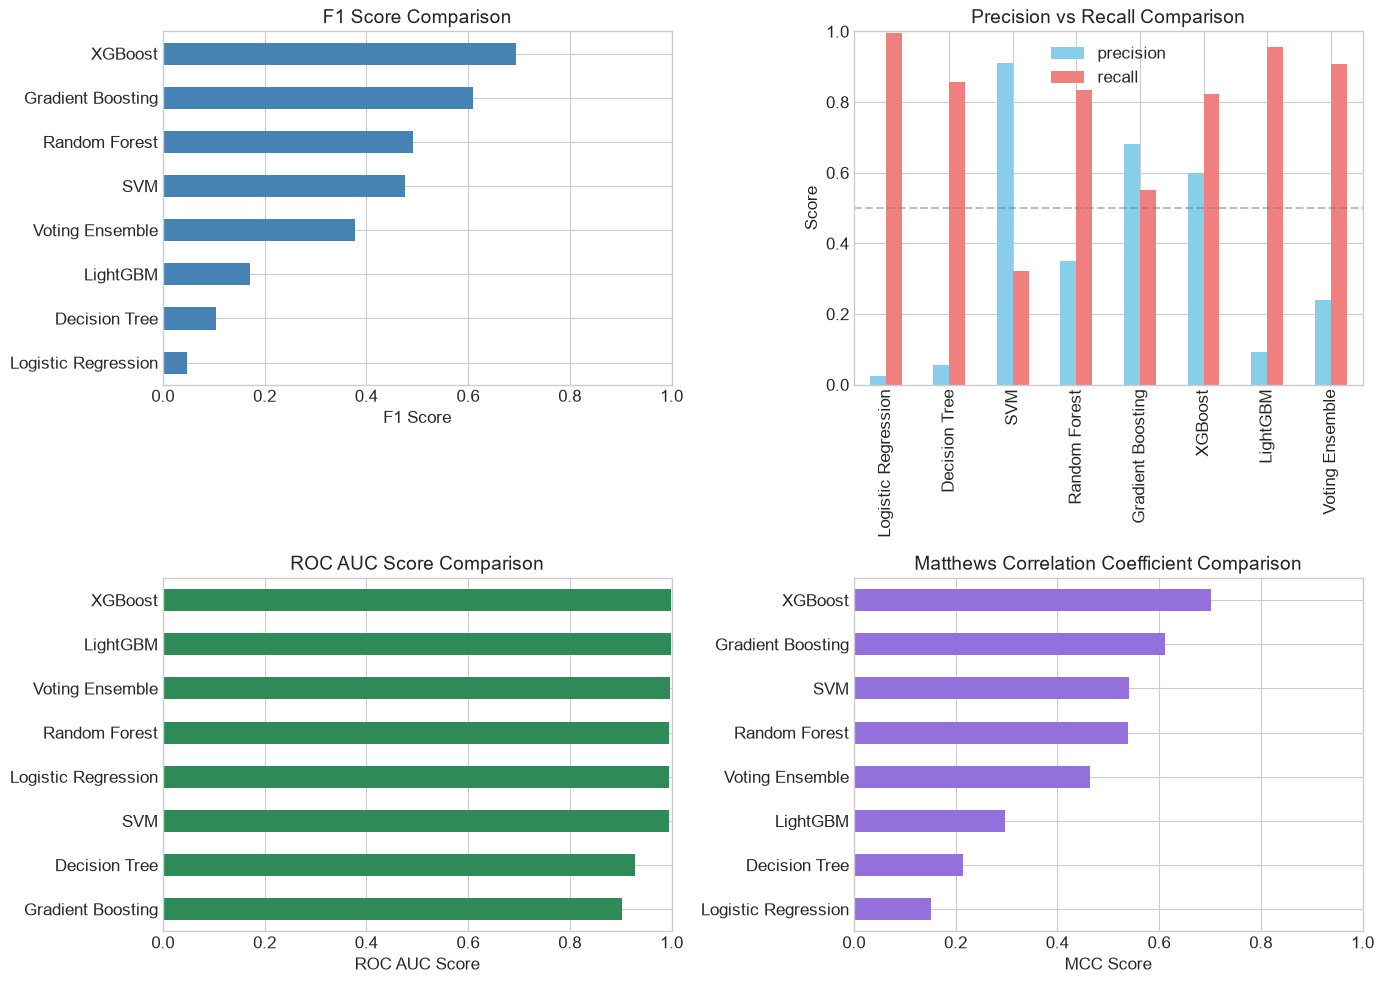

✓ Model comparison saved to ./reports/figures/model_comparison.png


In [39]:
# VISUALIZE EVALUATION RESULTS
# Create comparison dataframe
results_df = pd.DataFrame(evaluation_results).T

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# F1 Score
ax1 = axes[0, 0]
results_df['f1'].sort_values().plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('F1 Score Comparison')
ax1.set_xlabel('F1 Score')
ax1.set_xlim(0, 1)

# Precision vs Recall
ax2 = axes[0, 1]
results_df[['precision', 'recall']].plot(kind='bar', ax=ax2, color=['skyblue', 'lightcoral'])
ax2.set_title('Precision vs Recall Comparison')
ax2.set_ylabel('Score')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# ROC AUC
ax3 = axes[1, 0]
roc_auc_values = results_df['roc_auc'].dropna()
if len(roc_auc_values) > 0:
    roc_auc_values.sort_values().plot(kind='barh', ax=ax3, color='seagreen')
    ax3.set_title('ROC AUC Score Comparison')
    ax3.set_xlabel('ROC AUC Score')
    ax3.set_xlim(0, 1)

# MCC Score
ax4 = axes[1, 1]
results_df['mcc'].sort_values().plot(kind='barh', ax=ax4, color='mediumpurple')
ax4.set_title('Matthews Correlation Coefficient Comparison')
ax4.set_xlabel('MCC Score')
ax4.set_xlim(0, 1)

plt.tight_layout()
os.makedirs('./reports/figures', exist_ok=True)
plt.savefig('./reports/figures/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Model comparison saved to ./reports/figures/model_comparison.png")